# PyPI Downloads Econometric Analysis

This notebook performs econometric analysis of the treatment effects on PyPI downloads.

**Experiment context:**
- Treatment period: May 12-20, 2023
- Data period: April 25 - October 31, 2023 (189 days)
- Treatment groups: `treated2` (0=control, 1=low dosage, 2=high dosage)

**Analysis approach:**
- Difference-in-Differences
- Panel Fixed Effects
- Event Study (Dynamic Treatment Effects)
- Cumulative Event Study
- Hausman Test (FE vs RE)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS, RandomEffects
from scipy import stats

sns.set_theme(context="notebook", font_scale=1.1, style="whitegrid")

from utilities import save_mpl_fig

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("../input/pkg_pypi_downloads.csv").assign(
    date=lambda x: pd.to_datetime(x["date"])
)

print(f"Total observations: {len(df):,}")
print(f"Unique packages: {df['pkg'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Days: {df['date'].nunique()}")
print(f"\nTreatment distribution (treated2):")
print(df.groupby('treated2')['pkg'].nunique())

Total observations: 118,180
Unique packages: 622
Date range: 2023-04-25 to 2023-10-31
Days: 190

Treatment distribution (treated2):
treated2
0    522
1     75
2     25
Name: pkg, dtype: int64


In [3]:
treatment_end = pd.Timestamp('2023-05-20')

df['post'] = (df['date'] > treatment_end).astype(int)
df['event_time'] = (df['date'] - treatment_end).dt.days
df['treated'] = (df['treated2'] > 0).astype(int)

print("NaN counts:")
print(df[['download_count', 'tt_downloads']].isna().sum())

df = df.dropna(subset=['download_count', 'tt_downloads']).reset_index(drop=True)
df['pkg_id'] = pd.factorize(df['pkg'])[0]

print(f"\nAfter cleaning: {len(df):,} observations")
print("Pre/post treatment distribution:")
print(df.groupby('post')['date'].agg(['min', 'max', 'count']))
print(f"\nEvent time range: {df['event_time'].min()} to {df['event_time'].max()}")
print(f"Reference period: event_time = -1 (May 19, 2023)")

NaN counts:
download_count    6
tt_downloads      6
dtype: int64

After cleaning: 118,174 observations
Pre/post treatment distribution:
            min        max   count
post                              
0    2023-04-25 2023-05-20   16172
1    2023-05-21 2023-10-31  102002

Event time range: -25 to 164
Reference period: event_time = -1 (May 19, 2023)


## 2. Descriptive Statistics

In [4]:
outcomes = ['download_count', 'tt_downloads']

print("Mean outcomes by treatment and period:")
summary = df.groupby(['treated', 'post'])[outcomes].mean().round(3)
print(summary)

Mean outcomes by treatment and period:
              download_count  tt_downloads
treated post                              
0       0              9.863       131.363
        1             15.079      1345.817
1       0              7.229        90.545
        1             34.321      2247.768


In [5]:
pre_df = df[df['post'] == 0]

pre_pkg = pre_df.groupby(['pkg', 'treated'])[outcomes].sum().reset_index()

print("Pre-Treatment Balance Table (Apr 25 - May 20, 2023)")
print("="*70)
print(f"{'Variable':25s} {'Control':>10s} {'Treatment':>12s} {'Diff':>10s} {'p-value':>10s}")
print("-"*70)

for outcome in outcomes:
    c = pre_pkg[pre_pkg['treated'] == 0][outcome]
    t = pre_pkg[pre_pkg['treated'] == 1][outcome]
    
    c_mean, t_mean = c.mean(), t.mean()
    diff = t_mean - c_mean
    _, pval = stats.ttest_ind(c, t)
    
    sig = '*' if pval < 0.05 else ''
    print(f"{outcome:25s} {c_mean:10.2f} {t_mean:12.2f} {diff:+10.2f} {pval:10.4f} {sig}")

Pre-Treatment Balance Table (Apr 25 - May 20, 2023)
Variable                     Control    Treatment       Diff    p-value
----------------------------------------------------------------------
download_count                256.45       187.96     -68.49     0.6392 
tt_downloads                 3415.44      2354.18   -1061.26     0.4949 


## 3. Difference-in-Differences

In [6]:
print("Difference-in-Differences Regressions")
print("="*70)

did_results = {}

for outcome in outcomes:
    formula = f"{outcome} ~ treated * post"
    model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['pkg_id'].values})
    
    did_coef = model.params.get('treated:post', 0)
    did_se = model.bse.get('treated:post', 0)
    did_pval = model.pvalues.get('treated:post', 1)
    
    did_results[outcome] = {
        'coef': did_coef,
        'se': did_se,
        'pval': did_pval
    }
    
    stars = '***' if did_pval < 0.001 else '**' if did_pval < 0.01 else '*' if did_pval < 0.05 else ''
    print(f"{outcome:25s}: DiD = {did_coef:10.4f} (SE={did_se:.4f}) p={did_pval:.4f} {stars}")

print("\nNote: Clustered standard errors at package level")

Difference-in-Differences Regressions
download_count           : DiD =    21.8760 (SE=28.9790) p=0.4503 
tt_downloads             : DiD =   942.7684 (SE=1955.0748) p=0.6297 

Note: Clustered standard errors at package level


In [7]:
print("\nDiD with Heterogeneous Treatment (Low/High Dosage)")
print("="*70)

df['low_dose'] = (df['treated2'] == 1).astype(int)
df['high_dose'] = (df['treated2'] == 2).astype(int)

did_dosage_results = {}

for outcome in outcomes:
    formula = f"{outcome} ~ low_dose * post + high_dose * post"
    model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['pkg_id'].values})
    
    low_coef = model.params.get('low_dose:post', 0)
    low_pval = model.pvalues.get('low_dose:post', 1)
    high_coef = model.params.get('high_dose:post', 0)
    high_pval = model.pvalues.get('high_dose:post', 1)
    
    did_dosage_results[outcome] = {
        'low_coef': low_coef, 'low_pval': low_pval,
        'high_coef': high_coef, 'high_pval': high_pval
    }
    
    low_stars = '***' if low_pval < 0.001 else '**' if low_pval < 0.01 else '*' if low_pval < 0.05 else ''
    high_stars = '***' if high_pval < 0.001 else '**' if high_pval < 0.01 else '*' if high_pval < 0.05 else ''
    
    print(f"{outcome}:")
    print(f"  Low dosage:  {low_coef:10.4f} (p={low_pval:.4f}) {low_stars}")
    print(f"  High dosage: {high_coef:10.4f} (p={high_pval:.4f}) {high_stars}")


DiD with Heterogeneous Treatment (Low/High Dosage)
download_count:
  Low dosage:     -7.2956 (p=0.1606) 
  High dosage:   109.3911 (p=0.3303) 
tt_downloads:
  Low dosage:   -984.8997 (p=0.0690) 
  High dosage:  6725.7725 (p=0.3644) 


## 4. Panel Fixed Effects

In [8]:
panel_df = df.set_index(['pkg', 'date'])
panel_df['treatment_post'] = panel_df['treated'] * panel_df['post']

In [9]:
print("Panel Fixed Effects Regressions (Package FE)")
print("="*70)

fe_results = {}

for outcome in outcomes:
    exog = panel_df[['treatment_post', 'post']]
    exog = sm.add_constant(exog)
    
    model = PanelOLS(panel_df[outcome], exog, entity_effects=True)
    result = model.fit(cov_type='clustered', cluster_entity=True)
    
    coef = result.params.get('treatment_post', 0)
    se = result.std_errors.get('treatment_post', 0)
    pval = result.pvalues.get('treatment_post', 1)
    
    fe_results[outcome] = {
        'coef': coef,
        'se': se,
        'pval': pval
    }
    
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"{outcome:25s}: FE = {coef:10.4f} (SE={se:.4f}) p={pval:.4f} {stars}")

print("\nNote: Entity-clustered standard errors")

Panel Fixed Effects Regressions (Package FE)
download_count           : FE =    21.8769 (SE=28.9556) p=0.4499 
tt_downloads             : FE =   942.8416 (SE=1953.4934) p=0.6293 

Note: Entity-clustered standard errors


## 5. Event Study Design (Dynamic Treatment Effects)

Event study allows us to:
1. Test parallel trends assumption (pre-treatment coefficients should be ~0)
2. See dynamic treatment effects over time
3. Visualize the treatment effect trajectory

In [10]:
print("Event time distribution:")
print(f"Event time range: {df['event_time'].min()} to {df['event_time'].max()}")
print(f"Pre-treatment days: {len(df[df['event_time'] < 0]['event_time'].unique())}")
print(f"Post-treatment days: {len(df[df['event_time'] >= 0]['event_time'].unique())}")
print("\nReference period: event_time = -1 (May 19, 2023)")

Event time distribution:
Event time range: -25 to 164
Pre-treatment days: 25
Post-treatment days: 165

Reference period: event_time = -1 (May 19, 2023)


In [11]:
event_times = sorted(df['event_time'].unique())
event_times_for_dummies = [t for t in event_times if t != -1]

for k in event_times_for_dummies:
    col_name = f'treat_x_t{k}' if k < 0 else f'treat_x_t_plus_{k}'
    df[col_name] = (df['treated'] * (df['event_time'] == k)).astype(int)

print(f"Created {len(event_times_for_dummies)} event time interaction dummies")

Created 189 event time interaction dummies


In [12]:
panel_es = df.set_index(['pkg', 'date'])

interaction_cols = [f'treat_x_t{k}' if k < 0 else f'treat_x_t_plus_{k}' for k in event_times_for_dummies]

event_study_results = {}

for outcome in outcomes:
    exog = panel_es[interaction_cols].copy()
    exog = sm.add_constant(exog)
    
    model = PanelOLS(panel_es[outcome], exog, entity_effects=True, time_effects=True)
    result = model.fit(cov_type='clustered', cluster_entity=True)
    
    coefs = []
    for k in event_times_for_dummies:
        col = f'treat_x_t{k}' if k < 0 else f'treat_x_t_plus_{k}'
        coefs.append({
            'event_time': k,
            'coef': result.params.get(col, 0),
            'se': result.std_errors.get(col, 0),
            'pval': result.pvalues.get(col, 1)
        })
    
    coefs.append({'event_time': -1, 'coef': 0, 'se': 0, 'pval': 1})
    event_study_results[outcome] = pd.DataFrame(coefs).sort_values('event_time')

print("Event study regressions complete for all outcomes")

Event study regressions complete for all outcomes


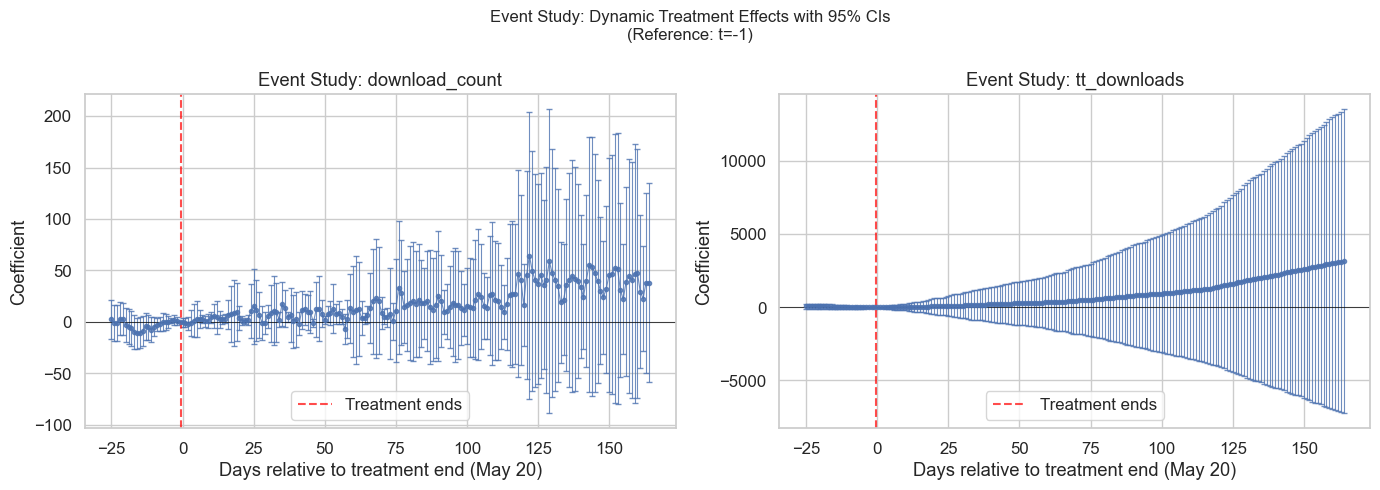

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, outcome in enumerate(outcomes):
    ax = axes[i]
    es_df = event_study_results[outcome]
    
    ax.errorbar(es_df['event_time'], es_df['coef'],
                yerr=1.96 * es_df['se'], fmt='o-', capsize=2, capthick=1,
                markersize=3, linewidth=0.8, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.7, label='Treatment ends')
    ax.set_xlabel('Days relative to treatment end (May 20)')
    ax.set_ylabel('Coefficient')
    ax.set_title(f'Event Study: {outcome}')
    ax.legend()

plt.suptitle('Event Study: Dynamic Treatment Effects with 95% CIs\n(Reference: t=-1)', fontsize=12)
plt.tight_layout()
save_mpl_fig("pypi_downloads_event_study")
plt.show()

In [14]:
print("Event Study Coefficients (download_count)")
print("="*70)
es_df = event_study_results['download_count']

print("\nPre-treatment (should be ~0 for parallel trends):")
pre_es = es_df[es_df['event_time'] < 0]
for _, row in pre_es.iterrows():
    t = int(row['event_time'])
    stars = '***' if row['pval'] < 0.001 else '**' if row['pval'] < 0.01 else '*' if row['pval'] < 0.05 else ''
    ci_low = row['coef'] - 1.96 * row['se']
    ci_high = row['coef'] + 1.96 * row['se']
    print(f"  t={t:+3d}: {row['coef']:8.3f} [{ci_low:8.3f}, {ci_high:8.3f}] {stars}")

print("\nPost-treatment (first 10 days):")
post_es = es_df[(es_df['event_time'] >= 0) & (es_df['event_time'] <= 10)]
for _, row in post_es.iterrows():
    t = int(row['event_time'])
    stars = '***' if row['pval'] < 0.001 else '**' if row['pval'] < 0.01 else '*' if row['pval'] < 0.05 else ''
    ci_low = row['coef'] - 1.96 * row['se']
    ci_high = row['coef'] + 1.96 * row['se']
    print(f"  t={t:+3d}: {row['coef']:8.3f} [{ci_low:8.3f}, {ci_high:8.3f}] {stars}")

Event Study Coefficients (download_count)

Pre-treatment (should be ~0 for parallel trends):
  t=-25:    2.541 [ -16.279,   21.361] 
  t=-24:   -1.026 [ -18.405,   16.354] 
  t=-23:   -0.954 [ -18.201,   16.294] 
  t=-22:    3.013 [ -12.960,   18.987] 
  t=-21:    2.601 [ -12.805,   18.007] 
  t=-20:   -2.508 [ -18.995,   13.980] 
  t=-19:   -4.528 [ -21.347,   12.291] 
  t=-18:   -6.042 [ -23.038,   10.953] 
  t=-17:   -9.815 [ -26.009,    6.380] 
  t=-16:  -11.028 [ -26.068,    4.012] 
  t=-15:  -10.319 [ -25.017,    4.379] 
  t=-14:   -8.637 [ -23.241,    5.967] 
  t=-13:   -4.390 [ -17.127,    8.348] 
  t=-12:   -5.297 [ -17.221,    6.627] 
  t=-11:   -7.349 [ -19.079,    4.380] 
  t=-10:   -4.444 [ -13.529,    4.641] 
  t= -9:   -2.540 [  -9.206,    4.126] 
  t= -8:   -1.779 [  -8.463,    4.906] 
  t= -7:   -0.126 [  -8.814,    8.563] 
  t= -6:    0.049 [  -7.951,    8.049] 
  t= -5:    0.157 [  -5.815,    6.130] 
  t= -4:    1.231 [  -1.271,    3.733] 
  t= -3:    1.847 [  -3.292

## 6. Cumulative Event Study

This shows the accumulated treatment effect over time - useful for understanding total impact rather than just daily changes.

In [15]:
panel_cum = df.set_index(['pkg', 'date'])

cum_event_study_results = {}

exog = panel_cum[interaction_cols].copy()
exog = sm.add_constant(exog)

model = PanelOLS(panel_cum['tt_downloads'], exog, entity_effects=True, time_effects=True)
result = model.fit(cov_type='clustered', cluster_entity=True)

coefs = []
for k in event_times_for_dummies:
    col = f'treat_x_t{k}' if k < 0 else f'treat_x_t_plus_{k}'
    coefs.append({
        'event_time': k,
        'coef': result.params.get(col, 0),
        'se': result.std_errors.get(col, 0),
        'pval': result.pvalues.get(col, 1)
    })

coefs.append({'event_time': -1, 'coef': 0, 'se': 0, 'pval': 1})
cum_event_study_results['tt_downloads'] = pd.DataFrame(coefs).sort_values('event_time')

print("Cumulative event study regression complete")

Cumulative event study regression complete


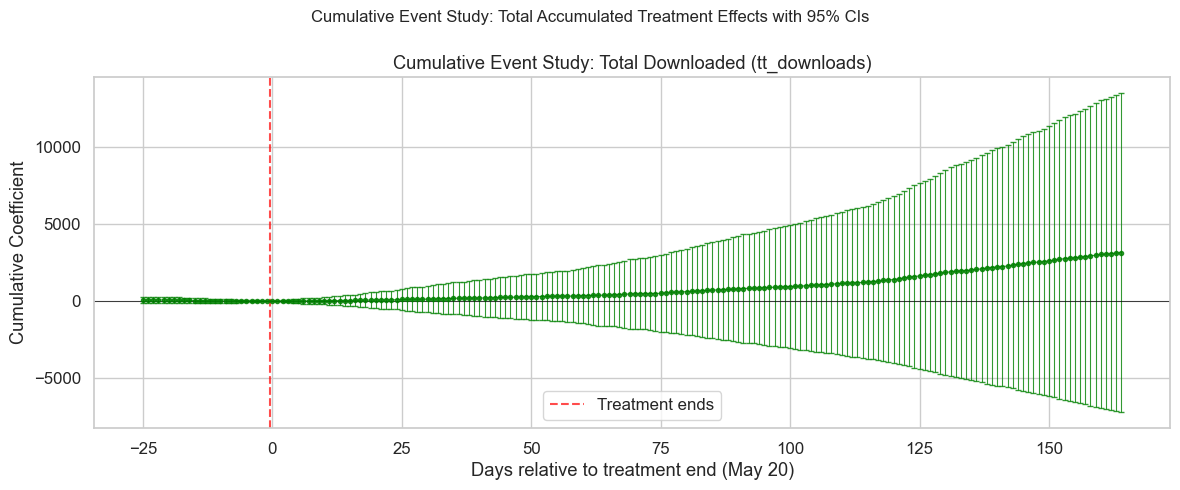

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

es_df = cum_event_study_results['tt_downloads']

ax.errorbar(es_df['event_time'], es_df['coef'],
            yerr=1.96 * es_df['se'], fmt='o-', capsize=2, capthick=1,
            markersize=3, linewidth=0.8, alpha=0.8, color='green')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.7, label='Treatment ends')
ax.set_xlabel('Days relative to treatment end (May 20)')
ax.set_ylabel('Cumulative Coefficient')
ax.set_title('Cumulative Event Study: Total Downloaded (tt_downloads)')
ax.legend()

plt.suptitle('Cumulative Event Study: Total Accumulated Treatment Effects with 95% CIs', fontsize=12)
plt.tight_layout()
save_mpl_fig("pypi_downloads_cumulative_event_study")
plt.show()

## 7. Hausman Test: Fixed Effects vs Random Effects

The Hausman test compares FE and RE estimators:
- H0: RE is consistent (no correlation between entity effects and regressors)
- H1: RE is inconsistent -> use FE

If p < 0.05, we reject H0 and prefer Fixed Effects.

In [17]:
def hausman_test(fe_result, re_result):
    common_params = list(set(fe_result.params.index) & set(re_result.params.index))
    common_params = [p for p in common_params if p != 'const']
    
    if not common_params:
        return np.nan, np.nan
    
    b_fe = fe_result.params[common_params].values
    b_re = re_result.params[common_params].values
    
    var_fe = fe_result.cov[common_params].loc[common_params].values
    var_re = re_result.cov[common_params].loc[common_params].values
    
    var_diff = var_fe - var_re
    
    try:
        diff = b_fe - b_re
        chi2 = diff @ np.linalg.pinv(var_diff) @ diff
        dof = len(common_params)
        pval = 1 - stats.chi2.cdf(chi2, dof)
        return chi2, pval
    except:
        return np.nan, np.nan


print("Hausman Test: FE vs RE")
print("="*70)

hausman_results = {}

for outcome in outcomes:
    exog = panel_df[['treatment_post', 'post']]
    exog = sm.add_constant(exog)
    
    fe_model = PanelOLS(panel_df[outcome], exog, entity_effects=True)
    fe_result = fe_model.fit()
    
    re_model = RandomEffects(panel_df[outcome], exog)
    re_result = re_model.fit()
    
    chi2, pval = hausman_test(fe_result, re_result)
    
    hausman_results[outcome] = {
        'chi2': chi2,
        'pval': pval,
        'fe_coef': fe_result.params.get('treatment_post', 0),
        're_coef': re_result.params.get('treatment_post', 0)
    }
    
    if np.isnan(pval):
        decision = "Unable to compute"
    elif pval < 0.05:
        decision = "Reject H0 -> Use FE"
    else:
        decision = "Fail to reject -> RE acceptable"
    
    print(f"{outcome:25s}: chi2={chi2:8.3f}, p={pval:.4f} | {decision}")

print("\nNote: Small p-value -> use Fixed Effects")

Hausman Test: FE vs RE
download_count           : chi2=   0.020, p=0.9902 | Fail to reject -> RE acceptable
tt_downloads             : chi2=   0.001, p=0.9995 | Fail to reject -> RE acceptable

Note: Small p-value -> use Fixed Effects


In [18]:
print("FE vs RE Coefficient Comparison (treatment_post)")
print("="*70)
print(f"{'Outcome':25s} {'FE Coef':>12s} {'RE Coef':>12s} {'Diff':>12s} {'Hausman p':>12s}")
print("-"*70)

for outcome in outcomes:
    h = hausman_results[outcome]
    diff = h['fe_coef'] - h['re_coef']
    print(f"{outcome:25s} {h['fe_coef']:12.4f} {h['re_coef']:12.4f} {diff:12.4f} {h['pval']:12.4f}")

FE vs RE Coefficient Comparison (treatment_post)
Outcome                        FE Coef      RE Coef         Diff    Hausman p
----------------------------------------------------------------------
download_count                 21.8769      21.8298       0.0471       0.9902
tt_downloads                  942.8416     941.8566       0.9850       0.9995


## 8. Summary

In [19]:
print("="*70)
print("SUMMARY: Effect of Bought Stars on PyPI Downloads")
print("="*70)
print(f"\nSample: {df['pkg'].nunique()} PyPI packages")
print(f"  Treatment: {df[df['treated']==1]['pkg'].nunique()} packages")
print(f"  Control: {df[df['treated']==0]['pkg'].nunique()} packages")
print(f"\nPeriod: April 25 - October 31, 2023 ({df['date'].nunique()} days)")
print(f"  Pre-treatment: Apr 25 - May 20, 2023")
print(f"  Post-treatment: May 21 - Oct 31, 2023")

print("\n" + "-"*70)
print("1. Difference-in-Differences Results:")
for outcome, res in did_results.items():
    stars = '***' if res['pval'] < 0.001 else '**' if res['pval'] < 0.01 else '*' if res['pval'] < 0.05 else ''
    print(f"   {outcome}: {res['coef']:.4f} (p={res['pval']:.4f}) {stars}")

print("\n2. Panel Fixed Effects Results:")
for outcome, res in fe_results.items():
    stars = '***' if res['pval'] < 0.001 else '**' if res['pval'] < 0.01 else '*' if res['pval'] < 0.05 else ''
    print(f"   {outcome}: {res['coef']:.4f} (p={res['pval']:.4f}) {stars}")

print("\n3. Event Study Findings:")
print("   Pre-treatment coefficients (parallel trends test):")
for outcome in outcomes:
    es_df = event_study_results[outcome]
    pre_sig = es_df[(es_df['event_time'] < 0) & (es_df['pval'] < 0.05)]
    if len(pre_sig) > 0:
        print(f"   - {outcome}: {len(pre_sig)} pre-treatment periods significant (parallel trends concern)")
    else:
        print(f"   - {outcome}: All pre-treatment coefficients insignificant (parallel trends supported)")

print("\n4. Hausman Test (FE vs RE):")
for outcome in outcomes:
    h = hausman_results[outcome]
    if h['pval'] < 0.05:
        decision = "FE preferred"
    else:
        decision = "RE acceptable"
    print(f"   - {outcome}: p={h['pval']:.4f} -> {decision}")

print("\n" + "="*70)

SUMMARY: Effect of Bought Stars on PyPI Downloads

Sample: 622 PyPI packages
  Treatment: 100 packages
  Control: 522 packages

Period: April 25 - October 31, 2023 (190 days)
  Pre-treatment: Apr 25 - May 20, 2023
  Post-treatment: May 21 - Oct 31, 2023

----------------------------------------------------------------------
1. Difference-in-Differences Results:
   download_count: 21.8760 (p=0.4503) 
   tt_downloads: 942.7684 (p=0.6297) 

2. Panel Fixed Effects Results:
   download_count: 21.8769 (p=0.4499) 
   tt_downloads: 942.8416 (p=0.6293) 

3. Event Study Findings:
   Pre-treatment coefficients (parallel trends test):
   - download_count: All pre-treatment coefficients insignificant (parallel trends supported)
   - tt_downloads: All pre-treatment coefficients insignificant (parallel trends supported)

4. Hausman Test (FE vs RE):
   - download_count: p=0.9902 -> RE acceptable
   - tt_downloads: p=0.9995 -> RE acceptable



## 9. Save Results

In [20]:
did_df = pd.DataFrame(did_results).T
did_df.index.name = 'outcome'
did_df.to_csv('../output/pypi_downloads_did_results.csv')

fe_df = pd.DataFrame(fe_results).T
fe_df.index.name = 'outcome'
fe_df.to_csv('../output/pypi_downloads_fe_results.csv')

for outcome in outcomes:
    event_study_results[outcome].to_csv(f'../output/pypi_downloads_event_study_{outcome}.csv', index=False)

cum_event_study_results['tt_downloads'].to_csv('../output/pypi_downloads_cumulative_event_study.csv', index=False)

print("Results saved to ../output/")
print("  - pypi_downloads_did_results.csv")
print("  - pypi_downloads_fe_results.csv")
print("  - pypi_downloads_event_study_download_count.csv")
print("  - pypi_downloads_event_study_tt_downloads.csv")
print("  - pypi_downloads_cumulative_event_study.csv")
print("  - pypi_downloads_event_study.png/pdf")
print("  - pypi_downloads_cumulative_event_study.png/pdf")

Results saved to ../output/
  - pypi_downloads_did_results.csv
  - pypi_downloads_fe_results.csv
  - pypi_downloads_event_study_download_count.csv
  - pypi_downloads_event_study_tt_downloads.csv
  - pypi_downloads_cumulative_event_study.csv
  - pypi_downloads_event_study.png/pdf
  - pypi_downloads_cumulative_event_study.png/pdf
